# Final paired-channel multiplexing analysis
___

## Importing libraries
___

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

import multiplexing_msd


## Analysis settings
___

In [2]:
# Input and output
RESULTS_DIR = multiplexing_msd.DEFAULT_RESULTS_ROOT
OUTPUT_DIR = NOTEBOOK_DIR / "results_multiplexing_msd"
SAVE_TABLES = True
SAVE_PLOTS = True

# Channels are the experimental conditions. Replace the labels with the
# correct biological names before preparing final figures.
CHANNELS = (0, 1)
CHANNEL_CONDITION_LABELS = {
    0: "SunTag-KDM5B",
    1: "UTag-KDM5B",
}

# Matched measurement channel for intensity and FWHM. The default means that
# tracks from channel 0 use spot_int_ch_0/spot_size_ch_0, and likewise for 1.
MEASUREMENT_CHANNEL_MAP = {0: 0, 1: 1}

# MSD calculation and fit settings
MAXIMUM_COMPUTED_LAG_FRAMES = None  # None calculates every available lag
MAXIMUM_FIT_LAG_FRAMES = 10
MAXIMUM_FIT_LAG_SECONDS = multiplexing_msd.fit_lag_seconds_from_frames(
    RESULTS_DIR, MAXIMUM_FIT_LAG_FRAMES
)
MINIMUM_CONTRIBUTORS_PER_LAG = 5
REMOVE_DRIFT = False

# Hierarchical spot-property reduction
TRAJECTORY_REDUCER = "median"  # "mean" or "median" over detections
CELL_REDUCER = "median"        # "mean" or "median" over trajectories

# Publication plot settings
PLOT_CHANNELS = CHANNELS
PLOT_CENTER = "median"         # "mean" or "median"
PLOT_UNCERTAINTY = "sem"     # "sem", "sd", "iqr", or "none"
MSD_SCALE = "linear"         # "linear" or "log"
MSD_ERROR_STYLE = "band"     # "bars" or "band"
MSD_DISPLAY_MAX_SECONDS = 100
MSD_NORMAL_FIT_MAX_SECONDS = MAXIMUM_FIT_LAG_SECONDS
SHOW_INDIVIDUAL_CELL_MSD = False
SHOW_TRAJECTORY_BACKGROUND = False
CONNECT_PAIRED_CELLS = False
SHOW_BOXPLOTS = True
SHOW_CELL_PLOT_LEGENDS = False
DISPLAY_UPPER_PERCENTILE = 95.0  # display only; tables/fits/tests retain all cells

# Paired cell-level inference (channels are paired within each cell).
RUN_PAIRED_TESTS = True
PAIRED_TEST = "wilcoxon"  # "wilcoxon", "paired_t", or "paired_t_log10"
STATISTICS_LABEL_STYLE = "stars"  # "stars" or "full"
STATISTICAL_METRICS = [
    "D_um2_s",
    "alpha",
    "K_alpha_um2_s_alpha",
    "cell_spot_intensity_au",
    "cell_spot_fwhm_nm",
    "n_trajectories",
    "median_trajectory_frames",
]

PLOT_DIR = OUTPUT_DIR / "plots" if SAVE_PLOTS else None


## Load and analyze results
___

In [3]:
analysis = multiplexing_msd.analyze_final_results(
    RESULTS_DIR,
    maximum_fit_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
    maximum_computed_lag_frames=MAXIMUM_COMPUTED_LAG_FRAMES,
    channels=CHANNELS,
    minimum_contributors_per_lag=MINIMUM_CONTRIBUTORS_PER_LAG,
    remove_drift=REMOVE_DRIFT,
    channel_condition_labels=CHANNEL_CONDITION_LABELS,
    measurement_channel_map=MEASUREMENT_CHANNEL_MAP,
    trajectory_reducer=TRAJECTORY_REDUCER,
    cell_reducer=CELL_REDUCER,
    verbose=True,
)

if RUN_PAIRED_TESTS:
    paired_statistics = multiplexing_msd.compute_paired_channel_statistics(
        analysis,
        metrics=STATISTICAL_METRICS,
        channel_pair=CHANNELS,
        test=PAIRED_TEST,
        adjust_fdr=True,
    )
    analysis["paired_channel_statistics"] = paired_statistics
else:
    paired_statistics = pd.DataFrame()

if SAVE_TABLES:
    written_tables = multiplexing_msd.save_final_tables(analysis, OUTPUT_DIR / "tables")
    print(f"Saved {len(written_tables)} tables to {OUTPUT_DIR / 'tables'}")

cell_table = analysis["cell_analysis_summary"]
frame_intervals = sorted(analysis["tracking_data"]["frame_interval_s"].unique())
if len(frame_intervals) != 1:
    raise ValueError(f"Expected one common frame interval, found {frame_intervals}")
expected_fit_seconds = MAXIMUM_FIT_LAG_FRAMES * frame_intervals[0]
if not np.isclose(MAXIMUM_FIT_LAG_SECONDS, expected_fit_seconds):
    raise ValueError(
        f"MAXIMUM_FIT_LAG_SECONDS={MAXIMUM_FIT_LAG_SECONDS:g} does not match "
        f"{MAXIMUM_FIT_LAG_FRAMES} frames × {frame_intervals[0]:g} s/frame "
        f"= {expected_fit_seconds:g} s."
    )
complete_pairs = (
    cell_table.groupby("global_cell_id")["channel"]
    .nunique()
    .eq(len(CHANNELS))
)
print(f"Cells: {cell_table['global_cell_id'].nunique()}")
print(f"Complete paired cells: {int(complete_pairs.sum())}")
print("Trajectories per channel:")
display(
    analysis["trajectory_summary"]
    .groupby(["channel", "channel_condition"])["global_particle_id"]
    .nunique()
    .rename("n_trajectories")
    .to_frame()
)


Loaded 13 valid result folders (0 invalid); channels=[0, 1].
Analyzed 26 cell/channel units. Trajectory totals by channel: {0: 373, 1: 821}
Final paired-channel table: 13 cells, 26 cell/channel rows, 13 complete channel sets.
Saved 12 tables to /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_8_Multiplexing/results_multiplexing_msd/tables
Cells: 13
Complete paired cells: 13
Trajectories per channel:


,,n_trajectories
channel,channel_condition,
0,SunTag-KDM5B,373
1,UTag-KDM5B,821


## Quality control
___

In [4]:
inventory_columns = [
    "source_id", "global_cell_id", "n_rows", "n_particles",
    "channels", "frame_interval_s", "xy_um_per_px", "is_3d",
]
display(analysis["dataset_inventory"][[
    column for column in inventory_columns
    if column in analysis["dataset_inventory"].columns
]])

qc_by_channel = (
    cell_table.groupby(["channel", "channel_condition"], as_index=False)
    .agg(
        n_cells=("global_cell_id", "nunique"),
        valid_normal_fits=("D_fit_valid", "sum"),
        valid_anomalous_fits=("anomalous_fit_valid", "sum"),
        total_trajectories=("n_trajectories", "sum"),
        missing_cell_intensity=("cell_spot_intensity_au", lambda value: int(value.isna().sum())),
        missing_cell_fwhm=("cell_spot_fwhm_nm", lambda value: int(value.isna().sum())),
    )
)
display(qc_by_channel)

excluded_fits = cell_table.loc[
    (~cell_table["D_fit_valid"].fillna(False))
    | (~cell_table["anomalous_fit_valid"].fillna(False)),
    [
        "global_cell_id", "channel", "channel_condition",
        "D_fit_valid", "normal_fit_exclusion_reason",
        "anomalous_fit_valid", "anomalous_fit_exclusion_reason",
    ],
]
display(excluded_fits)

msd_qc = multiplexing_msd.build_channel_msd_summary(
    analysis,
    channels=PLOT_CHANNELS,
    center=PLOT_CENTER,
    uncertainty=PLOT_UNCERTAINTY,
    maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
    normal_fit_max_lag_seconds=MSD_NORMAL_FIT_MAX_SECONDS,
)
display(msd_qc["summary"][[
    "channel", "channel_condition", "lag_frames", "lag_seconds", "n_cells"
]])


,source_id,n_rows,frame_interval_s,xy_um_per_px,is_3d
0,results_20260727_DISH2_Position 2,2445,5.0,0.129893,False
1,results_20260727_DISH2_Position 4,7248,5.0,0.129893,False
2,results_20260727_DISH2_Position 5,2060,5.0,0.129893,False
3,results_20260727_DISH2_Position 6,1687,5.0,0.129893,False
4,results_20260727_DISH2_Position 7,2165,5.0,0.129893,False
5,results_20260727_KDM5B_multiplexing_Position 10,3889,5.0,0.129893,False
6,results_20260727_KDM5B_multiplexing_Position 3,3709,5.0,0.129893,False
7,results_20260727_KDM5B_multiplexing_Position 4,3113,5.0,0.129893,False
8,results_20260727_KDM5B_multiplexing_Position 5,4644,5.0,0.129893,False
9,results_20260727_KDM5B_multiplexing_Position 7,2967,5.0,0.129893,False


,channel,channel_condition,n_cells,valid_normal_fits,valid_anomalous_fits,total_trajectories,missing_cell_intensity,missing_cell_fwhm
0,0,SunTag-KDM5B,13,13,9,373,0,0
1,1,UTag-KDM5B,13,13,12,821,0,0


,global_cell_id,channel,channel_condition,D_fit_valid,normal_fit_exclusion_reason,anomalous_fit_valid,anomalous_fit_exclusion_reason
12,results_20260727_KDM5B_multiplexing_Position 3...,0,SunTag-KDM5B,True,,False,K_alpha and the MSD offset are strongly correl...
16,results_20260727_KDM5B_multiplexing_Position 5...,0,SunTag-KDM5B,True,,False,K_alpha and the MSD offset are strongly correl...
20,results_20260727_KDM5B_multiplexing_Position 8...,0,SunTag-KDM5B,True,,False,K_alpha and the MSD offset are strongly correl...
23,results_20260727_KDM5B_multiplexing_Position 9...,1,UTag-KDM5B,True,,False,K_alpha and the MSD offset are strongly correl...
24,results_20260727_KDM5B_multiplexing_Series001:...,0,SunTag-KDM5B,True,,False,K_alpha and the MSD offset are strongly correl...


,channel,channel_condition,lag_frames,lag_seconds,n_cells
0,0,SunTag-KDM5B,1,5.0,13
1,0,SunTag-KDM5B,2,10.0,13
2,0,SunTag-KDM5B,3,15.0,13
3,0,SunTag-KDM5B,4,20.0,13
4,0,SunTag-KDM5B,5,25.0,13
...,...,...,...,...,...
93,1,UTag-KDM5B,45,225.0,10
94,1,UTag-KDM5B,46,230.0,10
95,1,UTag-KDM5B,47,235.0,9
96,1,UTag-KDM5B,48,240.0,9


## MSD versus time
___

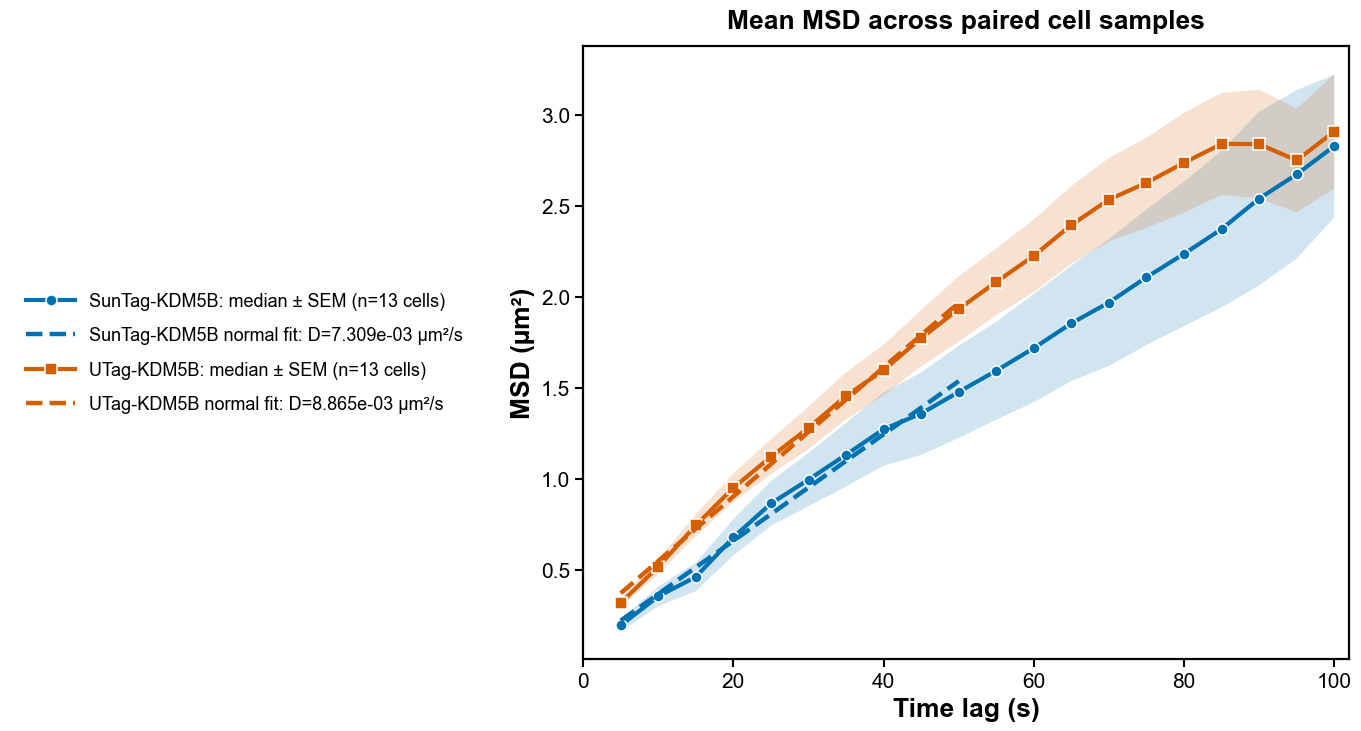

,channel,channel_condition,fit_points,fit_lag_start_s,fit_lag_end_s,dimension_factor,D_group_curve_um2_s,D_group_curve_se_um2_s,slope_um2_s,offset_um2,r_squared
0,0,SunTag-KDM5B,10,5.0,50.0,4.0,0.007309,0.000245,0.029235,0.075925,0.991115
1,1,UTag-KDM5B,10,5.0,50.0,4.0,0.008865,0.000201,0.035462,0.194800,0.995919


,channel,channel_condition,lag_frames,lag_seconds,n_cells,mean_msd_um2,median_msd_um2,center_msd_um2,sd_msd_um2,sem_msd_um2,q1_msd_um2,q3_msd_um2,lower_msd_um2,upper_msd_um2
0,0,SunTag-KDM5B,1,5.0,13,0.228620,0.195940,0.195940,0.121181,0.033609,0.124596,0.313346,0.162331,0.229550
1,0,SunTag-KDM5B,2,10.0,13,0.380697,0.355182,0.355182,0.195507,0.054224,0.191820,0.498244,0.300958,0.409406
2,0,SunTag-KDM5B,3,15.0,13,0.530724,0.462135,0.462135,0.282693,0.078405,0.249588,0.726827,0.383730,0.540540
3,0,SunTag-KDM5B,4,20.0,13,0.674835,0.679621,0.679621,0.359502,0.099708,0.343851,0.919147,0.579913,0.779329
4,0,SunTag-KDM5B,5,25.0,13,0.814329,0.865202,0.865202,0.442784,0.122806,0.415561,1.144510,0.742396,0.988008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,1,UTag-KDM5B,45,225.0,10,3.636072,3.215099,3.215099,2.060260,0.651511,2.143036,3.867346,2.563587,3.866610
94,1,UTag-KDM5B,46,230.0,10,3.670746,3.319882,3.319882,2.067475,0.653793,2.280011,3.891376,2.666089,3.973675
95,1,UTag-KDM5B,47,235.0,9,3.869450,3.417974,3.417974,2.322932,0.774311,2.310033,4.219668,2.643663,4.192284
96,1,UTag-KDM5B,48,240.0,9,3.885765,3.396838,3.396838,2.297187,0.765729,2.550151,3.957025,2.631109,4.162567


,global_cell_id,channel,channel_condition,included_in_cell_D,included_in_cell_MSD,included_in_both,cell_D_um2_s,n_consistent_cells,mean_cell_D_um2_s,median_cell_D_um2_s,D_group_curve_um2_s,group_D_minus_mean_cell_D_um2_s,identical_D_and_MSD_cell_sets
0,results_20260727_DISH2_Position 2::cell_0,0,SunTag-KDM5B,True,True,True,0.017409,13,0.006820,0.006963,0.007309,0.000489,True
1,results_20260727_DISH2_Position 4::cell_0,0,SunTag-KDM5B,True,True,True,0.010177,13,0.006820,0.006963,0.007309,0.000489,True
2,results_20260727_DISH2_Position 5::cell_0,0,SunTag-KDM5B,True,True,True,0.009597,13,0.006820,0.006963,0.007309,0.000489,True
3,results_20260727_DISH2_Position 6::cell_0,0,SunTag-KDM5B,True,True,True,0.005452,13,0.006820,0.006963,0.007309,0.000489,True
4,results_20260727_DISH2_Position 7::cell_0,0,SunTag-KDM5B,True,True,True,0.010201,13,0.006820,0.006963,0.007309,0.000489,True
5,results_20260727_KDM5B_multiplexing_Position 1...,0,SunTag-KDM5B,True,True,True,0.003618,13,0.006820,0.006963,0.007309,0.000489,True
6,results_20260727_KDM5B_multiplexing_Position 3...,0,SunTag-KDM5B,True,True,True,0.002128,13,0.006820,0.006963,0.007309,0.000489,True
7,results_20260727_KDM5B_multiplexing_Position 4...,0,SunTag-KDM5B,True,True,True,0.007668,13,0.006820,0.006963,0.007309,0.000489,True
8,results_20260727_KDM5B_multiplexing_Position 5...,0,SunTag-KDM5B,True,True,True,0.001898,13,0.006820,0.006963,0.007309,0.000489,True
9,results_20260727_KDM5B_multiplexing_Position 7...,0,SunTag-KDM5B,True,True,True,0.006963,13,0.006820,0.006963,0.007309,0.000489,True


In [5]:
msd_figure, msd_axis, msd_result = multiplexing_msd.plot_channel_msd(
    analysis,
    channels=PLOT_CHANNELS,
    center=PLOT_CENTER,
    uncertainty=PLOT_UNCERTAINTY,
    paired_cells_only=True,
    require_valid_normal_fit=True,
    show_individual_cells=SHOW_INDIVIDUAL_CELL_MSD,
    error_style=MSD_ERROR_STYLE,
    scale=MSD_SCALE,
    maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
    normal_fit_max_lag_seconds=MSD_NORMAL_FIT_MAX_SECONDS,
    legend_outside_left=True,
    output_directory=PLOT_DIR,
    show=True,
)
display(msd_result["fit_summary"])
display(msd_result["summary"])
display(msd_result["D_msd_consistency"])


## Diffusion metrics
___

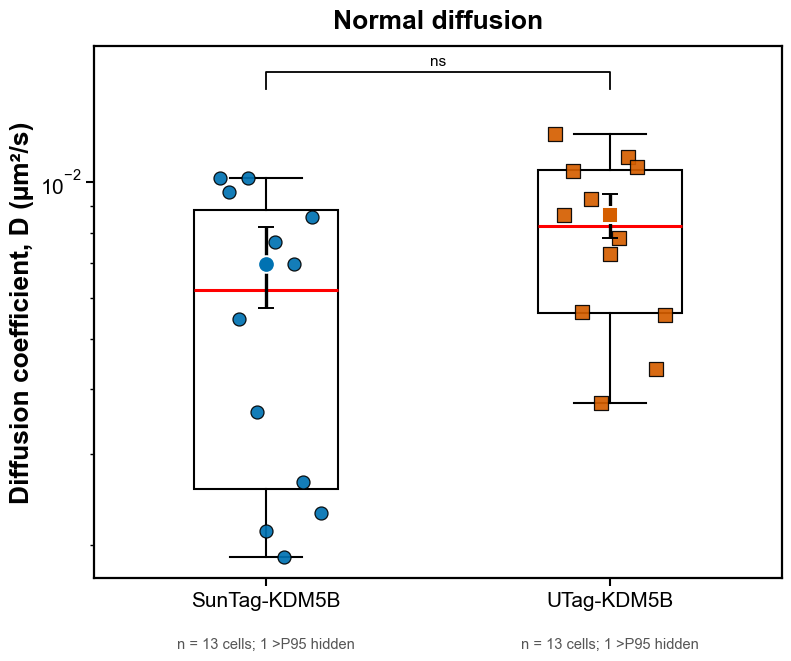

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,D_um2_s,0,SunTag-KDM5B,13,0.006820,0.006963,0.006963,0.004495,0.001247,0.002648,0.009597,0.005716,0.008210,95.0,0.013084,1
1,D_um2_s,1,UTag-KDM5B,13,0.008478,0.008660,0.008660,0.003046,0.000845,0.005622,0.010701,0.007815,0.009505,95.0,0.012657,1


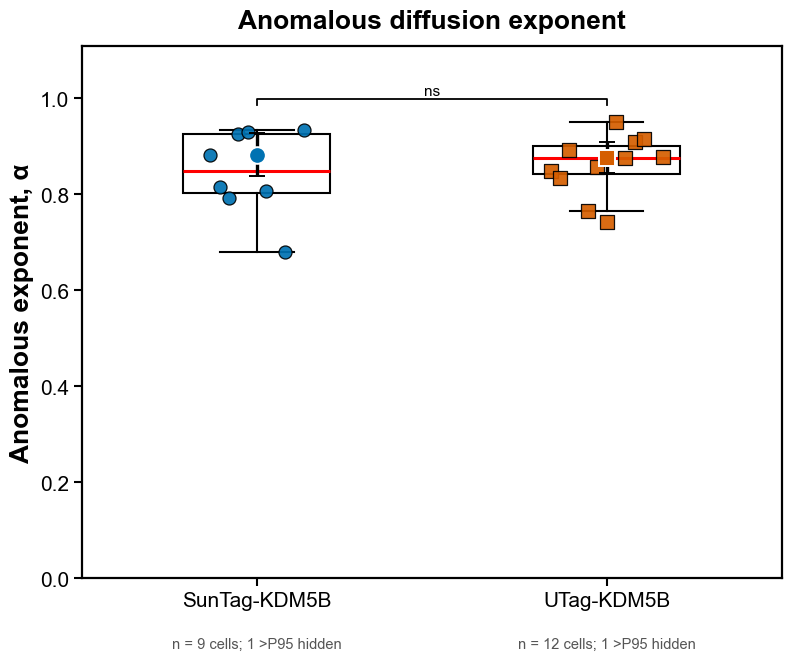

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,alpha,0,SunTag-KDM5B,9,0.880644,0.882869,0.882869,0.133677,0.044559,0.807680,0.930065,0.838310,0.927428,95.0,1.069392,1
1,alpha,1,UTag-KDM5B,12,0.889128,0.876689,0.876689,0.114002,0.032910,0.844748,0.911387,0.843779,0.909598,95.0,1.061910,1


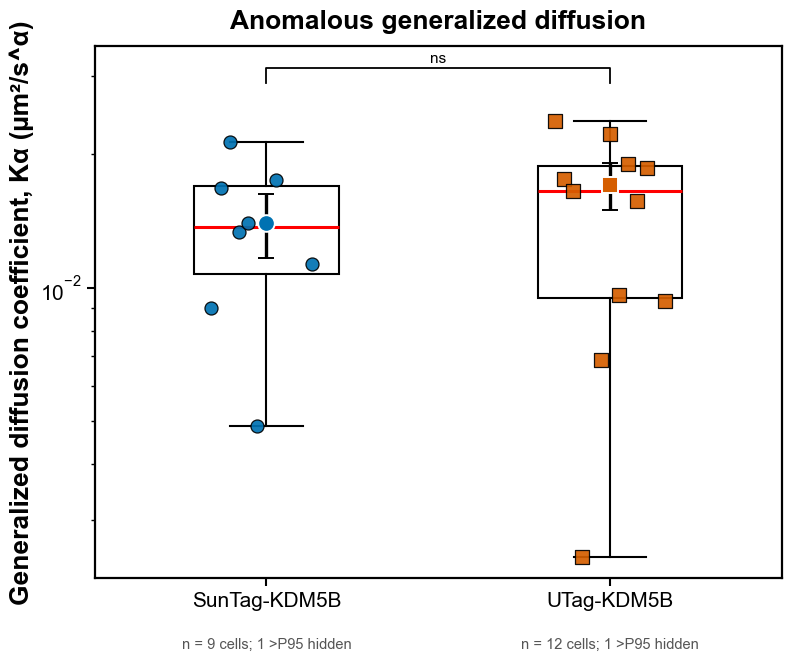

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,K_alpha_um2_s_alpha,0,SunTag-KDM5B,9,0.015162,0.014003,0.014003,0.006913,0.002304,0.011322,0.017534,0.011699,0.016308,95.0,0.025507,1
1,K_alpha_um2_s_alpha,1,UTag-KDM5B,12,0.015628,0.017053,0.017053,0.007144,0.002062,0.009554,0.019844,0.014990,0.019115,95.0,0.024626,1


,global_cell_id,channel,channel_condition,n_trajectories,D_um2_s,D_fit_valid,alpha,K_alpha_um2_s_alpha,anomalous_fit_valid,classification,normal_fit_exclusion_reason,anomalous_fit_exclusion_reason
0,results_20260727_DISH2_Position 2::cell_0,0,SunTag-KDM5B,35,0.017409,True,1.159117,0.008981,True,Superdiffusive over the fitted lag-time range,,
1,results_20260727_DISH2_Position 2::cell_0,1,UTag-KDM5B,51,0.012390,True,0.847964,0.023748,True,Subdiffusive over the fitted lag-time range,,
2,results_20260727_DISH2_Position 4::cell_0,0,SunTag-KDM5B,124,0.010177,True,0.882869,0.016767,True,Subdiffusive over the fitted lag-time range,,
3,results_20260727_DISH2_Position 4::cell_0,1,UTag-KDM5B,145,0.008660,True,0.835101,0.017557,True,Subdiffusive over the fitted lag-time range,,
4,results_20260727_DISH2_Position 5::cell_0,0,SunTag-KDM5B,20,0.009597,True,0.814759,0.021270,True,Subdiffusive over the fitted lag-time range,,
5,results_20260727_DISH2_Position 5::cell_0,1,UTag-KDM5B,47,0.010506,True,0.893301,0.016548,True,Subdiffusive over the fitted lag-time range,,
6,results_20260727_DISH2_Position 6::cell_0,0,SunTag-KDM5B,14,0.005452,True,0.791607,0.013382,True,Subdiffusive over the fitted lag-time range,,
7,results_20260727_DISH2_Position 6::cell_0,1,UTag-KDM5B,33,0.005622,True,1.197616,0.002477,True,Compatible with normal diffusion over the fitt...,,
8,results_20260727_DISH2_Position 7::cell_0,0,SunTag-KDM5B,22,0.010201,True,0.925342,0.014003,True,Compatible with normal diffusion over the fitt...,,
9,results_20260727_DISH2_Position 7::cell_0,1,UTag-KDM5B,48,0.009305,True,0.765090,0.025699,True,Subdiffusive over the fitted lag-time range,,


In [6]:
for metric, use_log_scale in [
    ("D_um2_s", True),
    ("alpha", False),
    ("K_alpha_um2_s_alpha", True),
]:
    figure, axis, metric_summary = multiplexing_msd.plot_cell_metric(
        analysis,
        metric=metric,
        channels=PLOT_CHANNELS,
        center=PLOT_CENTER,
        uncertainty=PLOT_UNCERTAINTY,
        show_trajectory_background=False,
        connect_paired_cells=CONNECT_PAIRED_CELLS,
        show_box=SHOW_BOXPLOTS,
        log_scale=use_log_scale,
        display_upper_percentile=DISPLAY_UPPER_PERCENTILE,
        statistics=paired_statistics,
        statistics_label_style=STATISTICS_LABEL_STYLE,
        show_legend=SHOW_CELL_PLOT_LEGENDS,
        output_directory=PLOT_DIR,
        show=True,
    )
    display(metric_summary)

display(cell_table[[
    "global_cell_id", "channel", "channel_condition", "n_trajectories",
    "D_um2_s", "D_fit_valid", "alpha", "K_alpha_um2_s_alpha",
    "anomalous_fit_valid", "classification",
    "normal_fit_exclusion_reason", "anomalous_fit_exclusion_reason",
]])


## Matched-channel spot measurements
___

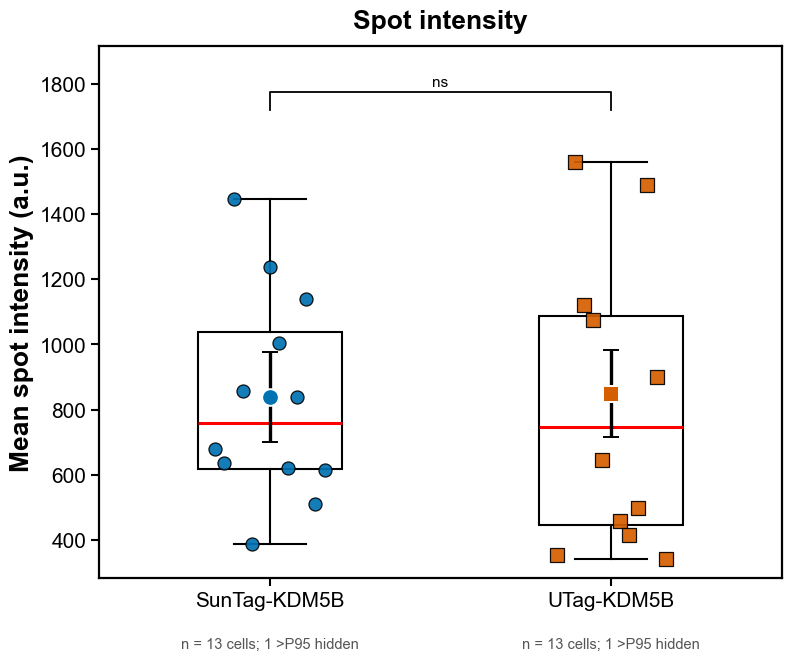

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,cell_spot_intensity_au,0,SunTag-KDM5B,13,940.665621,838.85710,838.85710,500.497242,138.812959,619.714275,1139.10200,700.044141,977.670059,95.0,1772.16328,1
1,cell_spot_intensity_au,1,UTag-KDM5B,13,876.995292,848.89795,848.89795,479.778000,133.066475,457.959200,1119.59185,715.831475,981.964425,95.0,1614.98776,1


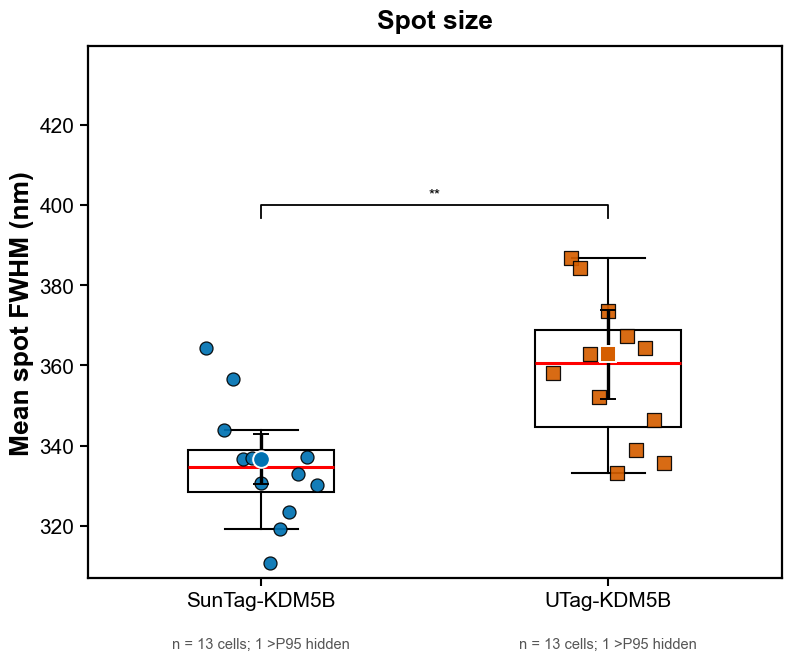

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,cell_spot_fwhm_nm,0,SunTag-KDM5B,13,339.928729,336.624696,336.624696,22.220840,6.162952,330.097563,343.824026,330.461744,342.787648,95.0,377.205926,1
1,cell_spot_fwhm_nm,1,UTag-KDM5B,13,368.717556,362.811163,362.811163,40.184669,11.145222,346.412148,373.533846,351.665941,373.956385,95.0,427.933114,1


,source_id,local_cell_id,global_cell_id,channel,channel_condition,measurement_channel,n_trajectories_spot_metrics,n_intensity_trajectories,n_fwhm_trajectories,cell_spot_intensity_au,cell_spot_fwhm_px,cell_spot_fwhm_um,cell_spot_fwhm_nm
0,results_20260727_DISH2_Position 2,0,results_20260727_DISH2_Position 2::cell_0,0,SunTag-KDM5B,0,35,35,35,680.000000,2.804150,0.364240,364.239988
1,results_20260727_DISH2_Position 2,0,results_20260727_DISH2_Position 2::cell_0,1,UTag-KDM5B,1,51,51,51,352.326550,2.757700,0.358206,358.206450
2,results_20260727_DISH2_Position 4,0,results_20260727_DISH2_Position 4::cell_0,0,SunTag-KDM5B,0,124,124,124,635.510225,3.053700,0.396655,396.654834
3,results_20260727_DISH2_Position 4,0,results_20260727_DISH2_Position 4::cell_0,1,UTag-KDM5B,1,145,145,145,1696.734700,3.769400,0.489619,489.619390
4,results_20260727_DISH2_Position 5,0,results_20260727_DISH2_Position 5::cell_0,0,SunTag-KDM5B,0,20,20,20,1447.918400,2.646975,0.343824,343.824026
5,results_20260727_DISH2_Position 5,0,results_20260727_DISH2_Position 5::cell_0,1,UTag-KDM5B,1,47,47,47,1560.489800,2.977900,0.386809,386.808930
6,results_20260727_DISH2_Position 6,0,results_20260727_DISH2_Position 6::cell_0,0,SunTag-KDM5B,0,14,14,14,855.673450,2.745700,0.356648,356.647731
7,results_20260727_DISH2_Position 6,0,results_20260727_DISH2_Position 6::cell_0,1,UTag-KDM5B,1,33,33,33,1119.591850,2.958100,0.384237,384.237045
8,results_20260727_DISH2_Position 7,0,results_20260727_DISH2_Position 7::cell_0,0,SunTag-KDM5B,0,22,22,22,388.816325,2.591550,0.336625,336.624696
9,results_20260727_DISH2_Position 7,0,results_20260727_DISH2_Position 7::cell_0,1,UTag-KDM5B,1,48,48,48,1075.510200,2.793150,0.362811,362.811163


In [7]:
for metric in ["cell_spot_intensity_au", "cell_spot_fwhm_nm"]:
    figure, axis, metric_summary = multiplexing_msd.plot_cell_metric(
        analysis,
        metric=metric,
        channels=PLOT_CHANNELS,
        center=PLOT_CENTER,
        uncertainty=PLOT_UNCERTAINTY,
        show_trajectory_background=SHOW_TRAJECTORY_BACKGROUND,
        connect_paired_cells=CONNECT_PAIRED_CELLS,
        show_box=SHOW_BOXPLOTS,
        log_scale=False,
        display_upper_percentile=DISPLAY_UPPER_PERCENTILE,
        statistics=paired_statistics,
        statistics_label_style=STATISTICS_LABEL_STYLE,
        show_legend=SHOW_CELL_PLOT_LEGENDS,
        output_directory=PLOT_DIR,
        show=True,
    )
    display(metric_summary)

display(analysis["cell_spot_summary"])


## Tracking yield and trajectory duration
___

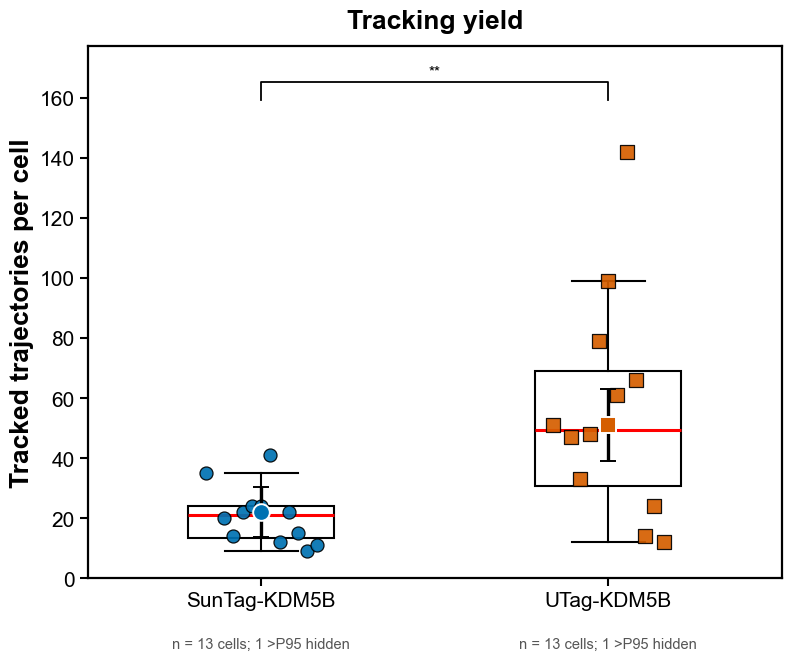

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,n_trajectories,0,SunTag-KDM5B,13,28.692308,22.0,22.0,30.092592,8.346183,14.0,24.0,13.653817,30.346183,95.0,74.2,1
1,n_trajectories,1,UTag-KDM5B,13,63.153846,51.0,51.0,43.375965,12.030328,33.0,79.0,38.969672,63.030328,95.0,143.2,1


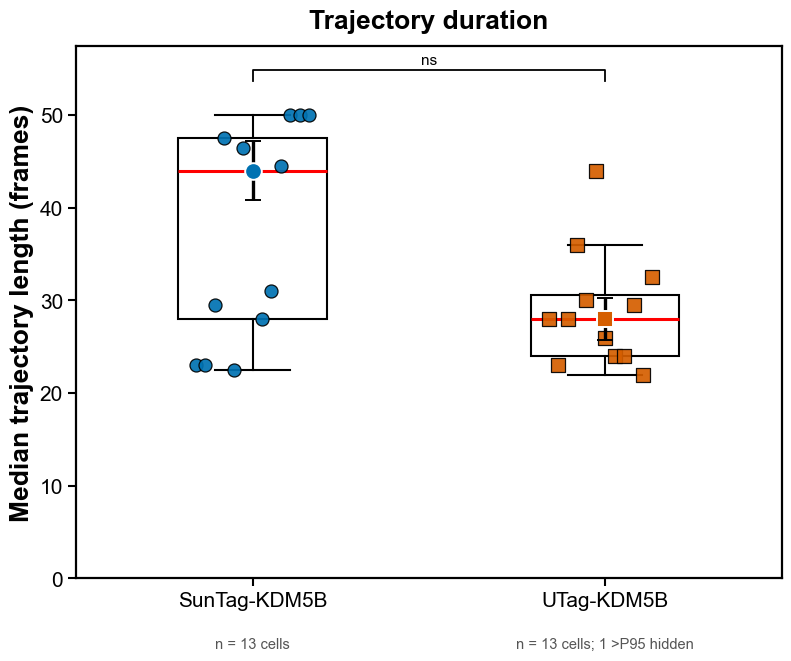

,metric,channel,channel_condition,n_cells,mean,median,center,sd,sem,q1,q3,lower,upper,display_upper_percentile,display_upper_threshold,n_cells_above_display_percentile
0,median_trajectory_frames,0,SunTag-KDM5B,13,37.653846,44.0,44.0,11.484382,3.185194,28.0,47.5,40.814806,47.185194,95.0,50.0,0
1,median_trajectory_frames,1,UTag-KDM5B,13,30.423077,28.0,28.0,8.100530,2.246683,24.0,32.5,25.753317,30.246683,95.0,45.8,1


In [8]:
for metric in ["n_trajectories", "median_trajectory_frames"]:
    figure, axis, metric_summary = multiplexing_msd.plot_cell_metric(
        analysis,
        metric=metric,
        channels=PLOT_CHANNELS,
        center=PLOT_CENTER,
        uncertainty=PLOT_UNCERTAINTY,
        show_trajectory_background=False,
        connect_paired_cells=CONNECT_PAIRED_CELLS,
        show_box=SHOW_BOXPLOTS,
        log_scale=False,
        display_upper_percentile=DISPLAY_UPPER_PERCENTILE,
        statistics=paired_statistics,
        statistics_label_style=STATISTICS_LABEL_STYLE,
        show_legend=SHOW_CELL_PLOT_LEGENDS,
        output_directory=PLOT_DIR,
        show=True,
    )
    display(metric_summary)


## Combined publication summary
___

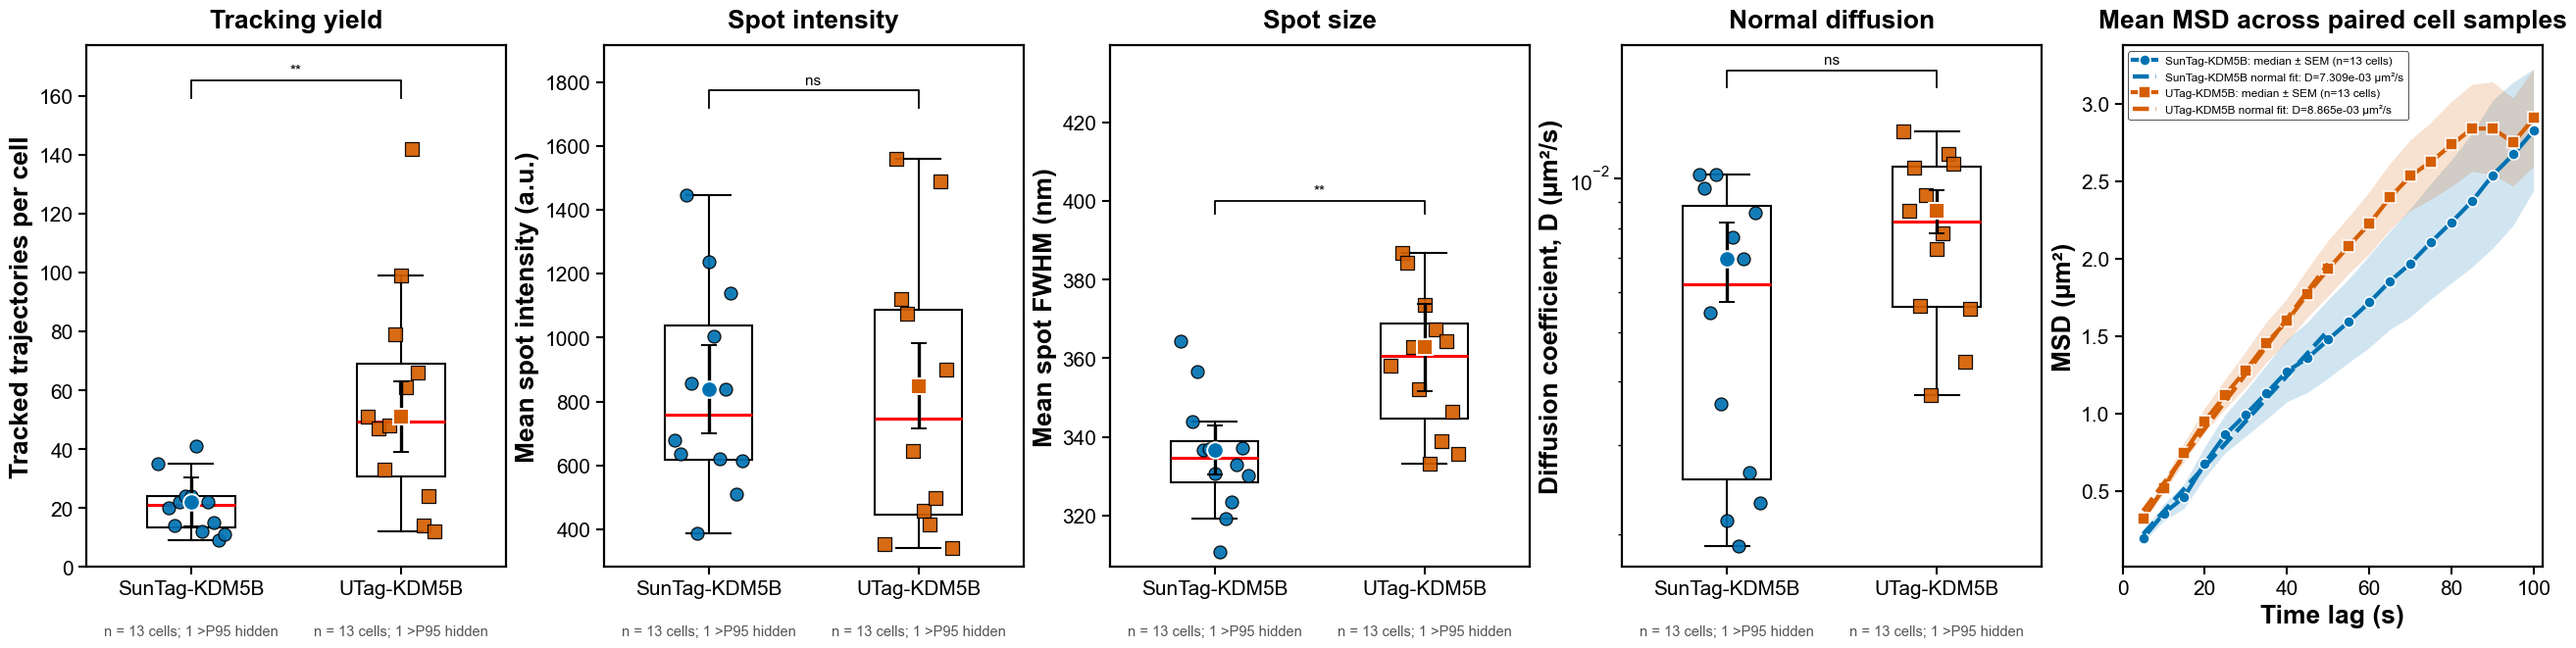

In [9]:
COMBINED_PANELS = [
    "n_trajectories",
    "cell_spot_intensity_au",
    "cell_spot_fwhm_nm",
    "D_um2_s",
    "msd",
]

combined_figure, combined_axes = multiplexing_msd.plot_combined_summary(
    analysis,
    panels=COMBINED_PANELS,
    channels=PLOT_CHANNELS,
    center=PLOT_CENTER,
    uncertainty=PLOT_UNCERTAINTY,
    show_trajectory_background=SHOW_TRAJECTORY_BACKGROUND,
    connect_paired_cells=CONNECT_PAIRED_CELLS,
    display_upper_percentile=DISPLAY_UPPER_PERCENTILE,
    msd_error_style="band",
    maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
    normal_fit_max_lag_seconds=MSD_NORMAL_FIT_MAX_SECONDS,
    statistics=paired_statistics,
    statistics_label_style=STATISTICS_LABEL_STYLE,
    output_directory=PLOT_DIR,
    show=True,
)


## Final tables
___

In [10]:
display(analysis["cell_analysis_summary"])
display(analysis["channel_condition_summary"])
display(paired_statistics)

print("Primary inferential unit: cell")
print("Paired conditions: tracking channels within each global_cell_id")
print("Source files pooled: yes")
print(
    f"Fit interval: first {MAXIMUM_FIT_LAG_FRAMES} positive lag frames "
    f"(0 < lag ≤ {MAXIMUM_FIT_LAG_SECONDS:g} s)"
)
print(f"Spatial calibration(s): {sorted(analysis['tracking_data']['xy_um_per_px'].unique())} µm/px")
print(f"Frame interval(s): {sorted(analysis['tracking_data']['frame_interval_s'].unique())} s/frame")


,source_id,local_cell_id,global_cell_id,channel,n_trajectories,median_trajectory_frames,D_um2_s,D_fit_valid,alpha,K_alpha_um2_s_alpha,...,normal_optimizer_success,normal_at_parameter_bound,normal_weakly_identified,normal_fit_status,anomalous_optimizer_success,anomalous_at_parameter_bound,anomalous_weakly_identified,anomalous_fit_status,normal_fit_exclusion_reason,anomalous_fit_exclusion_reason
0,results_20260727_DISH2_Position 2,0,results_20260727_DISH2_Position 2::cell_0,0,35,23.0,0.017409,True,1.159117,0.008981,...,True,False,False,,True,False,False,,,
1,results_20260727_DISH2_Position 2,0,results_20260727_DISH2_Position 2::cell_0,1,51,28.0,0.012390,True,0.847964,0.023748,...,True,False,False,,True,False,False,,,
2,results_20260727_DISH2_Position 4,0,results_20260727_DISH2_Position 4::cell_0,0,124,23.0,0.010177,True,0.882869,0.016767,...,True,False,False,,True,False,False,,,
3,results_20260727_DISH2_Position 4,0,results_20260727_DISH2_Position 4::cell_0,1,145,23.0,0.008660,True,0.835101,0.017557,...,True,False,False,,True,False,False,,,
4,results_20260727_DISH2_Position 5,0,results_20260727_DISH2_Position 5::cell_0,0,20,29.5,0.009597,True,0.814759,0.021270,...,True,False,False,,True,False,False,,,
5,results_20260727_DISH2_Position 5,0,results_20260727_DISH2_Position 5::cell_0,1,47,28.0,0.010506,True,0.893301,0.016548,...,True,False,False,,True,False,False,,,
6,results_20260727_DISH2_Position 6,0,results_20260727_DISH2_Position 6::cell_0,0,14,47.5,0.005452,True,0.791607,0.013382,...,True,False,False,,True,False,False,,,
7,results_20260727_DISH2_Position 6,0,results_20260727_DISH2_Position 6::cell_0,1,33,36.0,0.005622,True,1.197616,0.002477,...,True,False,False,,True,False,False,,,
8,results_20260727_DISH2_Position 7,0,results_20260727_DISH2_Position 7::cell_0,0,22,22.5,0.010201,True,0.925342,0.014003,...,True,False,False,,True,False,False,,,
9,results_20260727_DISH2_Position 7,0,results_20260727_DISH2_Position 7::cell_0,1,48,30.0,0.009305,True,0.765090,0.025699,...,True,False,False,,True,False,False,,,


,metric,unit,channel,channel_condition,n_cells,mean,sd,sem,median,q1,q3,minimum,maximum
0,D_um2_s,µm²/s,0,SunTag-KDM5B,13,0.006820,0.004495,0.001247,0.006963,0.002648,0.009597,0.001898,0.017409
1,D_um2_s,µm²/s,1,UTag-KDM5B,13,0.008478,0.003046,0.000845,0.008660,0.005622,0.010701,0.003755,0.013059
2,alpha,dimensionless,0,SunTag-KDM5B,9,0.880644,0.133677,0.044559,0.882869,0.807680,0.930065,0.679552,1.159117
3,alpha,dimensionless,1,UTag-KDM5B,12,0.889128,0.114002,0.032910,0.876689,0.844748,0.911387,0.742361,1.197616
4,K_alpha_um2_s_alpha,µm²/s^α,0,SunTag-KDM5B,9,0.015162,0.006913,0.002304,0.014003,0.011322,0.017534,0.004868,0.028331
5,K_alpha_um2_s_alpha,µm²/s^α,1,UTag-KDM5B,12,0.015628,0.007144,0.002062,0.017053,0.009554,0.019844,0.002477,0.025699
6,cell_spot_intensity_au,a.u.,0,SunTag-KDM5B,13,940.665621,500.497242,138.812959,838.857100,619.714275,1139.102000,388.816325,2258.530600
7,cell_spot_intensity_au,a.u.,1,UTag-KDM5B,13,876.995292,479.778000,133.066475,848.897950,457.959200,1119.591850,342.367325,1696.734700
8,cell_spot_fwhm_um,µm,0,SunTag-KDM5B,13,0.339929,0.022221,0.006163,0.336625,0.330098,0.343824,0.310633,0.396655
9,cell_spot_fwhm_um,µm,1,UTag-KDM5B,13,0.368718,0.040185,0.011145,0.362811,0.346412,0.373534,0.333254,0.489619


,metric,unit,channel_1,condition_1,channel_2,condition_2,n_paired_cells,test,log10_transformed,statistic,p_value,mean_condition_1,mean_condition_2,median_paired_difference_2_minus_1,median_paired_ratio_2_over_1,p_value_fdr_bh
0,D_um2_s,µm²/s,0,SunTag-KDM5B,1,UTag-KDM5B,13,wilcoxon,False,29.0,0.273438,0.006820,0.008478,0.000171,1.037808,0.478516
1,alpha,dimensionless,0,SunTag-KDM5B,1,UTag-KDM5B,8,wilcoxon,False,15.0,0.742188,0.873874,0.907233,0.015387,1.021147,0.945312
2,K_alpha_um2_s_alpha,µm²/s^α,0,SunTag-KDM5B,1,UTag-KDM5B,8,wilcoxon,False,17.0,0.945312,0.015642,0.014779,-0.001966,0.912549,0.945312
3,cell_spot_intensity_au,a.u.,0,SunTag-KDM5B,1,UTag-KDM5B,13,wilcoxon,False,43.0,0.892578,940.665621,876.995292,-205.265275,0.685114,0.945312
4,cell_spot_fwhm_nm,nm,0,SunTag-KDM5B,1,UTag-KDM5B,13,wilcoxon,False,2.0,0.000732,339.928729,368.717556,26.186467,1.077357,0.002563
5,n_trajectories,trajectories,0,SunTag-KDM5B,1,UTag-KDM5B,13,wilcoxon,False,1.5,0.000488,28.692308,63.153846,21.000000,2.350000,0.002563
6,median_trajectory_frames,frames,0,SunTag-KDM5B,1,UTag-KDM5B,13,wilcoxon,False,12.0,0.034102,37.653846,30.423077,-4.000000,0.857143,0.079570


Primary inferential unit: cell
Paired conditions: tracking channels within each global_cell_id
Source files pooled: yes
Fit interval: first 10 positive lag frames (0 < lag ≤ 50 s)
Spatial calibration(s): [0.12989318982387477] µm/px
Frame interval(s): [5.0] s/frame
